In [88]:
import pandas as pd
import numpy as np

In [89]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [90]:
df.drop("customerID", axis=1, inplace=True)

In [91]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isna().sum()
df[df["TotalCharges"].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [92]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [93]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

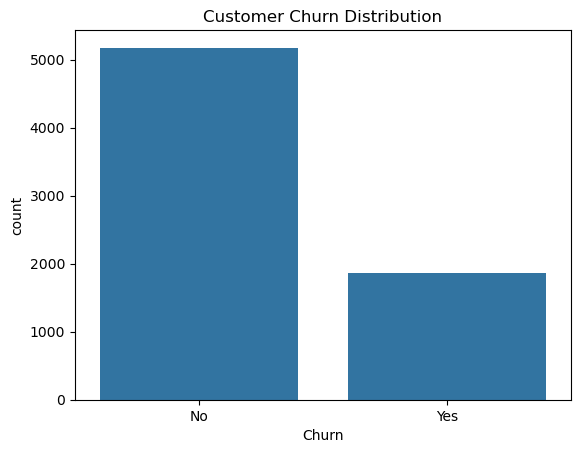

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [95]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [96]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Gender-churn correlation

In [97]:
pd.crosstab(df['gender'],df['Churn'], normalize='index')*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


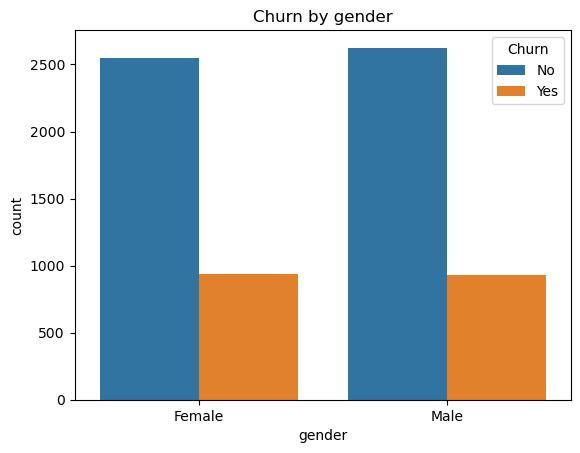

In [98]:
sns.countplot(data=df,x='gender',hue='Churn')
plt.title('Churn by gender')
plt.show()

# contract-churn correlation

In [99]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


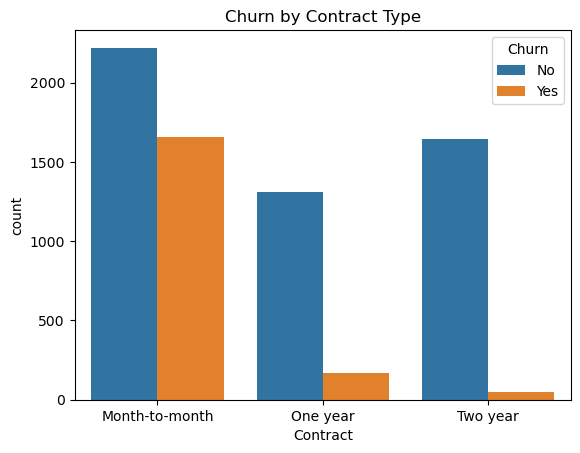

In [100]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

# Tenure-churn correlation

In [101]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

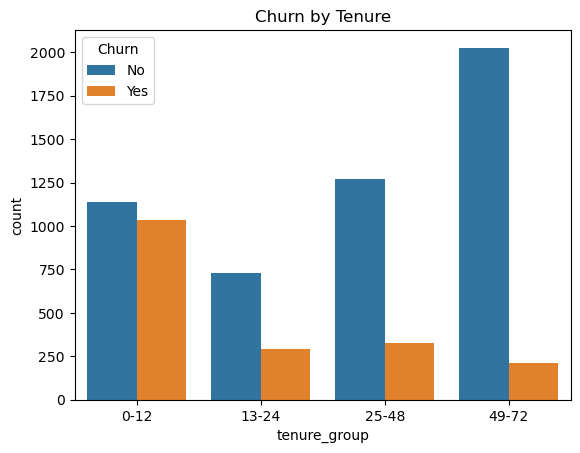

In [102]:
pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100
sns.countplot(data=df, x="tenure_group", hue="Churn")
plt.title("Churn by Tenure")
plt.show()

# Monthly Charges

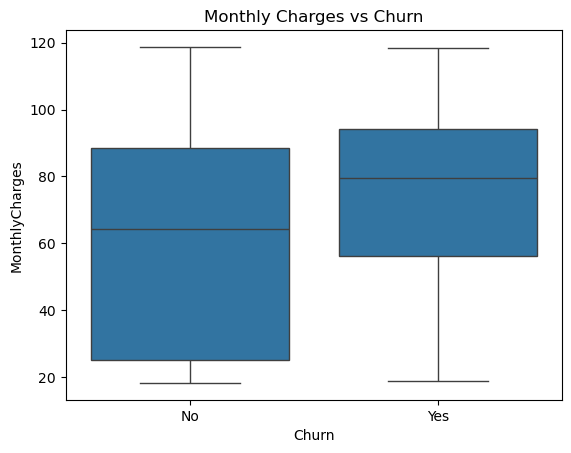

In [103]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

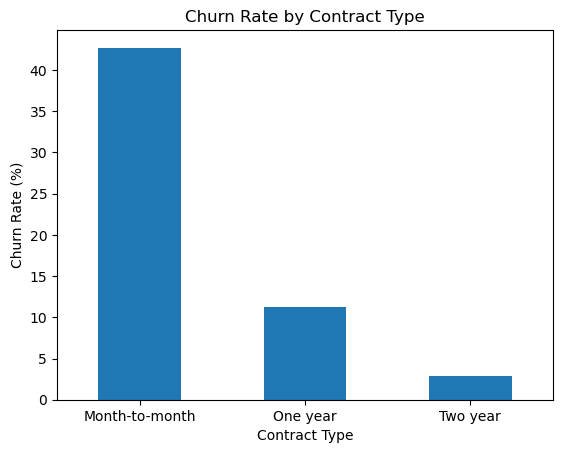

In [104]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn["Yes"].plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.show()

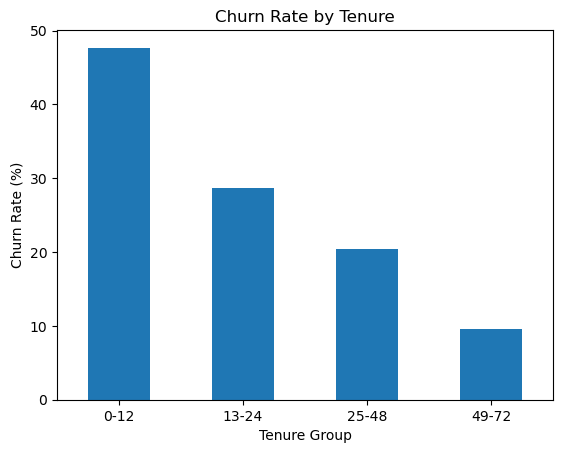

In [105]:
tenure_churn=pd.crosstab(df['tenure_group'],df['Churn'],normalize="index")*100
tenure_churn['Yes'].plot(kind='bar')
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group")
plt.title("Churn Rate by Tenure")
plt.xticks(rotation=0)
plt.show()

In [106]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


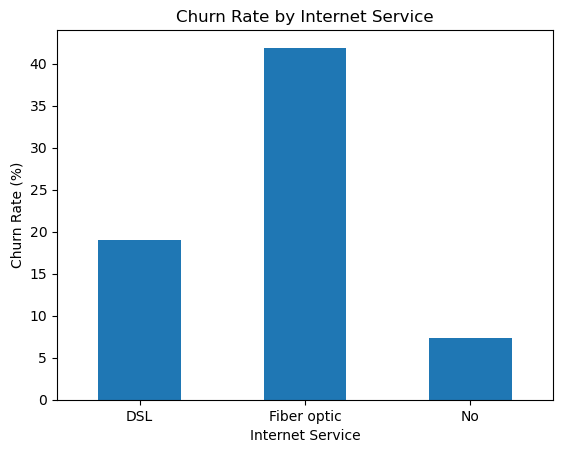

In [107]:
internet_churn["Yes"].plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Internet Service")
plt.title("Churn Rate by Internet Service")
plt.xticks(rotation=0)
plt.show()

In [108]:
features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

for feature in features:
    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100
    
    print("\n", feature)
    print(churn_rate["Yes"])


 OnlineSecurity
OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Yes, dtype: float64

 OnlineBackup
OnlineBackup
No                     39.928756
No internet service     7.404980
Yes                    21.531494
Name: Yes, dtype: float64

 DeviceProtection
DeviceProtection
No                     39.127625
No internet service     7.404980
Yes                    22.502064
Name: Yes, dtype: float64

 TechSupport
TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Yes, dtype: float64


In [109]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn["Yes"].sort_values(ascending=False))

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64


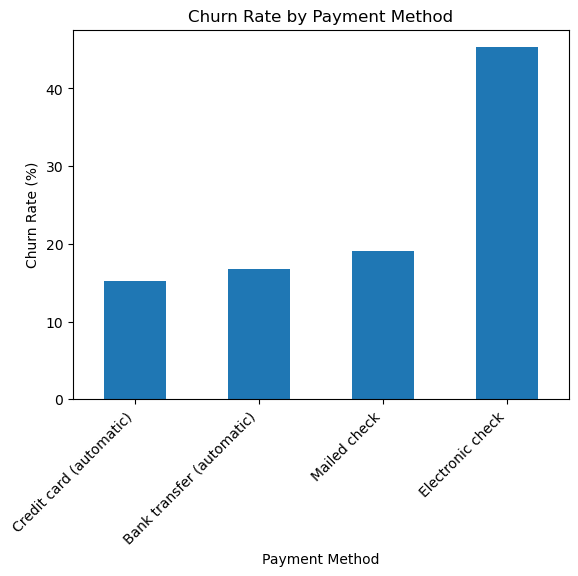

In [110]:
payment_churn["Yes"].sort_values().plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=45, ha="right")
plt.show()

In [111]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [112]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [113]:
df_model = df.copy()

In [114]:
df_model.drop('tenure_group',axis=1,inplace=True)
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [115]:
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [116]:
df_model["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [117]:
df_model.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

# Logistic regression

In [118]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [119]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [120]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

### For Logistic Regression, a cleaner approach is usually:OneHotEncoder(
    handle_unknown="ignore",
    drop="first")                                                                                                                                This removes one category from each categorical variable and makes the coefficients easier to interpret relative to a reference category.

In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",drop="first"), categorical_cols)
    ]
)

In [123]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [124]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [125]:
y_pred = logistic_model.predict(X_test)

In [126]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [127]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8069552874378992
Precision: 0.660377358490566
Recall   : 0.5614973262032086
F1 Score : 0.6069364161849711
ROC-AUC  : 0.8421710713270816


In [128]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



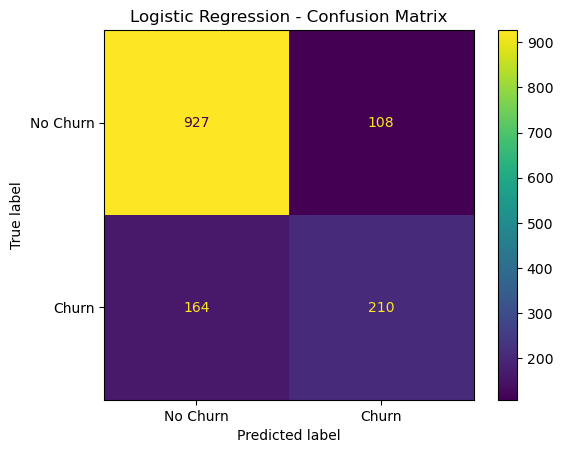

In [129]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## threshold tuning

In [130]:
import numpy as np

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.3f}"
    )

Threshold: 0.3 | Precision: 0.519 | Recall: 0.754 | F1: 0.615
Threshold: 0.4 | Precision: 0.571 | Recall: 0.668 | F1: 0.616
Threshold: 0.5 | Precision: 0.660 | Recall: 0.561 | F1: 0.607
Threshold: 0.6 | Precision: 0.718 | Recall: 0.401 | F1: 0.515
Threshold: 0.7 | Precision: 0.742 | Recall: 0.184 | F1: 0.296


# Random Forest

In [131]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

In [132]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [133]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [134]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.7835344215755855
Precision: 0.6210526315789474
Recall   : 0.4732620320855615
F1 Score : 0.5371775417298937
ROC-AUC  : 0.8226898137384071


In [135]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [136]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

In [137]:
coefficients = logistic_model.named_steps["classifier"].coef_[0]

In [138]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [139]:
coef_df.sort_values("Coefficient", ascending=False).head(15)

,Feature,Coefficient
10,cat__InternetService_Fiber optic,1.182298
3,num__TotalCharges,0.523110
28,cat__PaymentMethod_Electronic check,0.383863
21,cat__StreamingTV_Yes,0.377500
23,cat__StreamingMovies_Yes,0.376065
26,cat__PaperlessBilling_Yes,0.371284
9,cat__MultipleLines_Yes,0.362275
29,cat__PaymentMethod_Mailed check,0.075442
0,num__SeniorCitizen,0.054651
17,cat__DeviceProtection_Yes,0.035237


In [140]:
coef_df.sort_values("Coefficient", ascending=True).head(15)

,Feature,Coefficient
25,cat__Contract_Two year,-1.326384
1,num__tenure,-1.250481
24,cat__Contract_One year,-0.686597
7,cat__PhoneService_Yes,-0.505143
2,num__MonthlyCharges,-0.470779
13,cat__OnlineSecurity_Yes,-0.349623
19,cat__TechSupport_Yes,-0.297591
8,cat__MultipleLines_No phone service,-0.256658
6,cat__Dependents_Yes,-0.224945
18,cat__TechSupport_No internet service,-0.173381


In [141]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [142]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


In [147]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [150]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [151]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [152]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [153]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.8034066713981547
Precision: 0.6655290102389079
Recall   : 0.5213903743315508
F1 Score : 0.5847076461769115
ROC-AUC  : 0.8423183239040015


In [154]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



# Final take logistic regression with 0.3 threshold

In [155]:
final_prob = logistic_model.predict_proba(X_test)[:, 1]

final_pred = (final_prob >= 0.30).astype(int)

In [156]:
print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))

Accuracy : 0.7494677075940384
Precision: 0.5193370165745856
Recall   : 0.7540106951871658
F1 Score : 0.6150490730643402


In [157]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



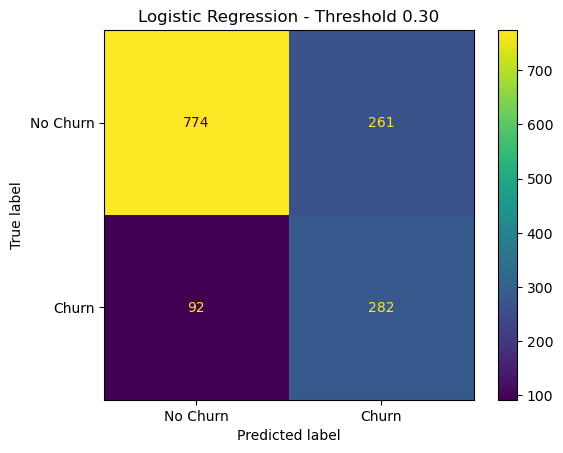

In [158]:
cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Threshold 0.30")
plt.show()

In [159]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [160]:
coef_df.sort_values(
    "Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
10,cat__InternetService_Fiber optic,1.182298
3,num__TotalCharges,0.523110
28,cat__PaymentMethod_Electronic check,0.383863
21,cat__StreamingTV_Yes,0.377500
23,cat__StreamingMovies_Yes,0.376065
26,cat__PaperlessBilling_Yes,0.371284
9,cat__MultipleLines_Yes,0.362275
29,cat__PaymentMethod_Mailed check,0.075442
0,num__SeniorCitizen,0.054651
17,cat__DeviceProtection_Yes,0.035237


In [161]:
coef_df.sort_values(
    "Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
25,cat__Contract_Two year,-1.326384
1,num__tenure,-1.250481
24,cat__Contract_One year,-0.686597
7,cat__PhoneService_Yes,-0.505143
2,num__MonthlyCharges,-0.470779
13,cat__OnlineSecurity_Yes,-0.349623
19,cat__TechSupport_Yes,-0.297591
8,cat__MultipleLines_No phone service,-0.256658
6,cat__Dependents_Yes,-0.224945
18,cat__TechSupport_No internet service,-0.173381


In [162]:
df_model[
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].corr()

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn,-0.352229,0.193356,-0.198324,1.000000


In [163]:
df_model[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


# experimenting by droppind total charges
## but accuracy dropped so commente it out

In [164]:
X_reduced = df_model.drop(
    ["Churn", "TotalCharges"],
    axis=1
)

y = df_model["Churn"]

In [165]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [166]:
categorical_cols_r = X_reduced.select_dtypes(
    include="object"
).columns

numerical_cols_r = X_reduced.select_dtypes(
    exclude="object"
).columns

In [167]:
preprocessor_r = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols_r),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ), categorical_cols_r)
    ]
)

In [168]:
logistic_reduced = Pipeline([
    ("preprocessor", preprocessor_r),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [169]:
logistic_reduced.fit(X_train_r, y_train_r)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [170]:
lr_r_pred = logistic_reduced.predict(X_test_r)
lr_r_prob = logistic_reduced.predict_proba(X_test_r)[:, 1]

In [171]:
print("Accuracy :", accuracy_score(y_test_r, lr_r_pred))
print("Precision:", precision_score(y_test_r, lr_r_pred))
print("Recall   :", recall_score(y_test_r, lr_r_pred))
print("F1 Score :", f1_score(y_test_r, lr_r_pred))
print("ROC-AUC  :", roc_auc_score(y_test_r, lr_r_prob))

Accuracy : 0.7970191625266146
Precision: 0.6375
Recall   : 0.5454545454545454
F1 Score : 0.5878962536023055
ROC-AUC  : 0.8393061045234959


In [172]:
risk_df = X_test.copy()

risk_df["ActualChurn"] = y_test
risk_df["ChurnProbability"] = final_prob

risk_df["RiskLevel"] = pd.cut(
    risk_df["ChurnProbability"],
    bins=[-float("inf"), 0.30, 0.70, float("inf")],
    labels=["Low", "Medium", "High"]
)

In [173]:
risk_df["RiskLevel"].value_counts()

RiskLevel
Low       866
Medium    450
High       93
Name: count, dtype: int64

In [174]:
risk_df.sort_values(
    "ChurnProbability",
    ascending=False
).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ActualChurn,ChurnProbability,RiskLevel
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,1,0.855107,High
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,1,0.832080,High
2631,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,1,0.827946,High
6365,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,1,0.823041,High
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,1,0.818811,High
3727,Female,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,96.60,291.90,1,0.818052,High
2797,Male,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,100.95,329.95,1,0.817840,High
6894,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,1,0.817163,High
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0,0.817010,High
935,Female,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,83.25,308.05,0,0.811211,High


In [177]:
risk_summary = pd.crosstab(
    risk_df["RiskLevel"],
    risk_df["ActualChurn"],
    normalize="index"
) * 100

risk_summary

ActualChurn,0,1
RiskLevel,,
Low,89.376443,10.623557
Medium,52.666667,47.333333
High,25.806452,74.193548


In [178]:
risk_churn_rate = risk_df.groupby(
    "RiskLevel",
    observed=True
)["ActualChurn"].mean() * 100

risk_churn_rate

RiskLevel
Low       10.623557
Medium    47.333333
High      74.193548
Name: ActualChurn, dtype: float64

In [179]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.806955,
        0.783534,
        0.803407
    ],
    "Precision": [
        0.660377,
        0.621053,
        0.665529
    ],
    "Recall": [
        0.561497,
        0.473262,
        0.521390
    ],
    "F1 Score": [
        0.606936,
        0.537178,
        0.584708
    ],
    "ROC-AUC": [
        0.842171,
        0.822690,
        0.842318
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Random Forest,0.783534,0.621053,0.473262,0.537178,0.822690
2,XGBoost,0.803407,0.665529,0.521390,0.584708,0.842318
